In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
raw_welfare = pd.read_spss('Koweps_hpwc14_2019_beta2.sav')
welfare = raw_welfare.copy()

welfare.shape       # 14418행, 830열

# 1. 일단 변수명을 바꾼다
welfare = welfare.rename(columns={'h14_g3'  :   'sex',
                                  'h14_g4'  :   'birth',
                                  'h14_g10' :   'marriage_type',
                                  'h14_g11' :   'religion',
                                  'p1402_8aq1'  :   'income',
                                  'h14_eco9'    :   'code_job',
                                  'h14_reg7'    :   'code_region'})
welfare

ImportError: Missing optional dependency 'pyreadstat'.  Use pip or conda to install pyreadstat.

## 종교유무에 따른 이혼율


<Axes: xlabel='marriage', ylabel='n'>

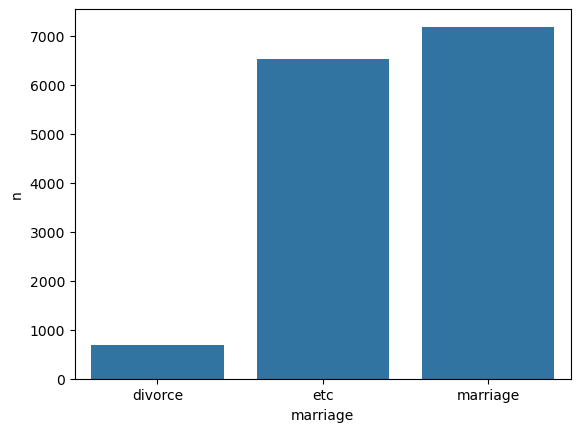

In [ ]:
# 종교 변수 체크
# welfare['religion'].dtypes
welfare['religion'] = np.where(welfare['religion'] == 1 , 'yes','no')


# marriage_type변수체크
# welfare['marriage_type'].dtypes
# welfare['marriage_type'].value_counts()
welfare['marriage'] = np.where(welfare['marriage_type'] == 1.0 , 'marriage',
                    np.where(welfare['marriage_type'] == 3.0, 'divorce','etc'))
n_divorce = welfare.groupby('marriage',as_index=False).agg(n = ('marriage','count'))

sns.barplot(data=n_divorce, x='marriage', y='n')
# 1.이혼자 수 2. 기타 수 3. 결혼자 수

<Axes: xlabel='religion', ylabel='pro'>

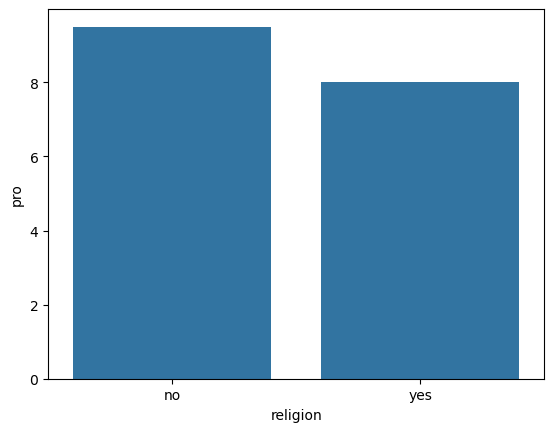

In [ ]:
# 문제는 이것을 비율로 표현하는것!
rel_div = welfare.query('marriage != "etc"').groupby('religion',as_index=False)['marriage'].value_counts(normalize=True)
rel_div = rel_div.query('marriage == "divorce"').assign(pro = rel_div['proportion'] * 100).round(1)

sns.barplot(data=rel_div, x='religion' ,y='pro')


In [ ]:
# 연령대,종교유무에 따른 이혼율은?

welfare = welfare.assign(age = 2019 - welfare['birth'] + 1) # 만나이 +1 계산
welfare['ageg'] = np.where(welfare['age'] >= 60, 'old',np.where(welfare['age'] > 30 , 'middle','young'))

age_div = welfare.query('marriage != "etc"').groupby('ageg',as_index=False)['marriage'].value_counts(normalize=True)
age_div.dtypes

NameError: name 'welfare' is not defined

In [ ]:
""